## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## Data

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# ===== LOAD DATA =====
data = pd.read_excel("/content/drive/MyDrive/PINNs/Suction_vsCP-modified_1.xlsx")

# Target
target = "Collapse Potential (%)"

# Input features
features = [
    'Suction (kPa)',
    'Silica fume (%)',
    'Lime (%)',
    'Gypsum content (%)',
    'Applied vertical stress (kPa)',
    'Degree of Saturation (%)'
]

X = data[features].values
y = data[target].values.reshape(-1, 1)

## Scaling

In [11]:
# ===== SCALE DATA =====
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

## Physics Rules (Domain Knowledge)

In [12]:
# +1 → increasing, -1 → decreasing
PHYSICS_RULES = {
    'Suction (kPa)': +1,
    'Silica fume (%)': +1,
    'Lime (%)': -1,
    'Gypsum content (%)': +1,
    'Applied vertical stress (kPa)': +1,
    'Degree of Saturation (%)': -1
}

## Finite-Difference Physics Penalty

In [13]:
def physics_penalty(model, X, feature_idx, direction, eps=1e-3):
    Xp = X.copy()
    Xm = X.copy()

    Xp[:, feature_idx] += eps
    Xm[:, feature_idx] -= eps

    yp = model.predict(Xp)
    ym = model.predict(Xm)

    dydx = (yp - ym) / (2 * eps)

    if direction == +1:
        return np.mean(np.maximum(0, -dydx))
    elif direction == -1:
        return np.mean(np.maximum(0, dydx))
    return 0.0

## Physics-Constrained RF Training Loop

In [14]:
def train_physics_rf(X, y, feature_names):
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X, y.ravel())

    penalty = 0.0
    for f, d in PHYSICS_RULES.items():
        idx = feature_names.index(f)
        penalty += physics_penalty(rf, X, idx, d)

    return rf, penalty

## K-Fold Cross Validation (Drop-in Replacement)
## K-Fold Cross Validation (NO MISSING VARIABLES)

In [15]:
kf = KFold(n_splits=4, shuffle=True, random_state=42)

rf_results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    print(f"\n===== Fold {fold+1} =====")

    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_scaled[train_idx], y_scaled[val_idx]

    model, phy_penalty = train_physics_rf(X_train, y_train, features)

    y_pred_scaled = model.predict(X_val).reshape(-1, 1)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_val)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"RMSE = {rmse:.4f}")
    print(f"R²   = {r2:.4f}")
    print(f"Physics Penalty = {phy_penalty:.4f}")

    rf_results.append((model, rmse, r2, phy_penalty))


===== Fold 1 =====
RMSE = 6.9456
R²   = 0.7835
Physics Penalty = 0.9636

===== Fold 2 =====
RMSE = 2.9735
R²   = 0.9660
Physics Penalty = 1.3095

===== Fold 3 =====
RMSE = 3.1936
R²   = 0.9302
Physics Penalty = 0.9799

===== Fold 4 =====
RMSE = 2.1563
R²   = 0.9594
Physics Penalty = 1.8300


## Select Best Model

In [16]:
best_model = sorted(rf_results, key=lambda x: x[1])[0][0]

In [17]:
best_model

RandomForestRegressor(max_depth=12, min_samples_leaf=5, n_estimators=500,
                      n_jobs=-1, random_state=42)

## Feature Importance

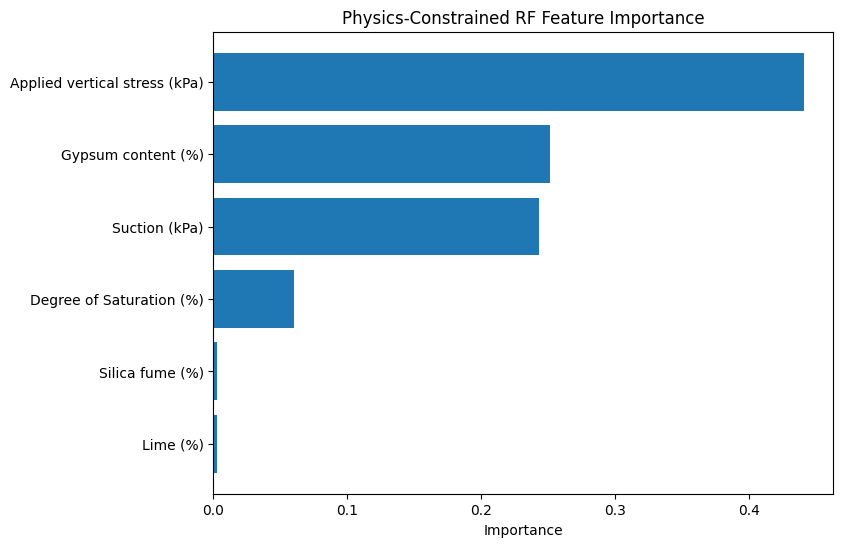

In [18]:
importances = best_model.feature_importances_
idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(np.array(features)[idx], importances[idx])
plt.xlabel("Importance")
plt.title("Physics-Constrained RF Feature Importance")
plt.show()

## ICE Plot (Physics Validation)

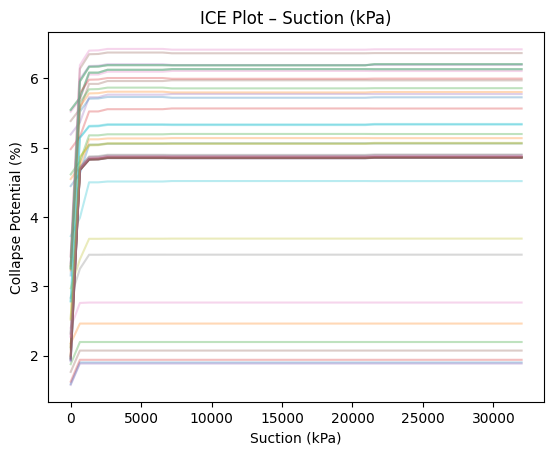

In [19]:
def ice_plot(model, X_scaled, feature_idx, name):
    X_base = scaler_X.inverse_transform(X_scaled[:50])
    values = np.linspace(
        X_base[:, feature_idx].min(),
        X_base[:, feature_idx].max(), 50
    )

    for row in X_base:
        preds = []
        for v in values:
            r = row.copy()
            r[feature_idx] = v
            xs = scaler_X.transform(r.reshape(1, -1))
            ys = model.predict(xs)
            preds.append(scaler_y.inverse_transform([[ys[0]]])[0][0])
        plt.plot(values, preds, alpha=0.3)

    plt.xlabel(name)
    plt.ylabel("Collapse Potential (%)")
    plt.title(f"ICE Plot – {name}")
    plt.show()

# Example
ice_plot(best_model, X_scaled, 0, features[0])

## Save Model

In [21]:
import os

path = "/content/drive/MyDrive/Physics-ConstrainedRandomForest"
os.makedirs(path, exist_ok=True)

joblib.dump(best_model, os.path.join(path, "physics_constrained_rf.pkl"))
joblib.dump(scaler_X, os.path.join(path, "scaler_X.pkl"))
joblib.dump(scaler_y, os.path.join(path, "scaler_y.pkl"))

['/content/drive/MyDrive/Physics-ConstrainedRandomForest/scaler_y.pkl']